# Q2.3 — Predicting Flat Type After a Data Loss Incident

**Scenario:** the `flat_type` column was mistakenly deleted from the transactions database. Backups
exist but will take time to restore. Build a stopgap model to predict `flat_type` from the other
(surviving) transaction characteristics, and explain why this model was chosen.

## Unsupervised apporach
Try different unsupervised methods

(this note book is a little messy, didnt work so didnt pursue it futher)


In [1]:
%load_ext autoreload
%autoreload 2

In [ ]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

curr_dir = Path.cwd()
DATA_DIR = curr_dir.parent.parent / "data"
SRC_DIR = curr_dir.parent
sys.path.append(str(SRC_DIR))

from utils import get_storey_mid

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler


## 1. Load data (full history)

In [2]:
master_df = pd.read_csv(DATA_DIR / "merged_resale_prices.csv", parse_dates=["month"])

print(f"Rows: {len(master_df):,}")
print(f"Date range: {master_df['month'].min().date()} to {master_df['month'].max().date()}")
master_df["flat_type"].value_counts()

Rows: 981,352
Date range: 1990-01-01 to 2026-07-01


flat_type
4 ROOM              375892
3 ROOM              309127
5 ROOM              207974
EXECUTIVE            72959
2 ROOM               13525
1 ROOM                1323
MULTI-GENERATION       552
Name: count, dtype: int64

In [6]:
master_df.floor_area_sqm.describe()

count    981352.000000
mean         95.660281
std          25.724331
min          28.000000
25%          73.000000
50%          93.000000
75%         113.000000
max         366.700000
Name: floor_area_sqm, dtype: float64

In [30]:

master_df[master_df["floor_area_sqm"]>150]

,month,town,flat_type,block,street_name,address,storey_range,floor_area_sqm,flat_model,lease_commence_date,flat_age_years,remaining_lease_years,resale_price,source_file
284,1990-01-01,BEDOK,EXECUTIVE,725,BEDOK RESERVOIR RD,725 BEDOK RESERVOIR RD,01 TO 03,151.0,MAISONETTE,1984,6,93,195000.0,"Resale Flat Prices (Based on Approval Date), 1..."
378,1990-01-01,BUKIT BATOK,EXECUTIVE,214,BT BATOK ST 21,214 BT BATOK ST 21,01 TO 03,154.0,MAISONETTE,1984,6,93,195000.0,"Resale Flat Prices (Based on Approval Date), 1..."
588,1990-01-01,CLEMENTI,EXECUTIVE,115,CLEMENTI ST 13,115 CLEMENTI ST 13,10 TO 12,163.0,MAISONETTE,1985,5,94,207000.0,"Resale Flat Prices (Based on Approval Date), 1..."
589,1990-01-01,CLEMENTI,EXECUTIVE,116,CLEMENTI ST 13,116 CLEMENTI ST 13,04 TO 06,151.0,MAISONETTE,1984,6,93,180000.0,"Resale Flat Prices (Based on Approval Date), 1..."
755,1990-01-01,HOUGANG,EXECUTIVE,132,LOR AH SOO,132 LOR AH SOO,07 TO 09,151.0,MAISONETTE,1984,6,93,190000.0,"Resale Flat Prices (Based on Approval Date), 1..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
980921,2026-07-01,PASIR RIS,EXECUTIVE,239,PASIR RIS ST 21,239 PASIR RIS ST 21,01 TO 03,159.0,Apartment,1993,33,66,898000.0,Resale flat prices based on registration date ...
981246,2026-07-01,WOODLANDS,EXECUTIVE,308,WOODLANDS AVE 1,308 WOODLANDS AVE 1,07 TO 09,192.0,Apartment,1994,32,67,1070000.0,Resale flat prices based on registration date ...
981247,2026-07-01,WOODLANDS,EXECUTIVE,331,WOODLANDS AVE 1,331 WOODLANDS AVE 1,04 TO 06,176.0,Apartment,1994,32,67,1020000.0,Resale flat prices based on registration date ...
981298,2026-07-01,WOODLANDS,EXECUTIVE,805,WOODLANDS ST 81,805 WOODLANDS ST 81,10 TO 12,189.0,Apartment,1994,32,67,1200000.0,Resale flat prices based on registration date ...


In [32]:
master_df.flat_model.value_counts()

flat_model
Model A                   216301
Improved                  181088
New Generation            116228
NEW GENERATION             78898
IMPROVED                   73589
MODEL A                    70381
Premium Apartment          52118
Simplified                 36331
Apartment                  27246
Standard                   26473
SIMPLIFIED                 23258
Maisonette                 18725
STANDARD                   17375
MAISONETTE                 12215
Model A2                   10716
APARTMENT                   9901
DBSS                        4029
Adjoined flat               1330
Model A-Maisonette          1179
MODEL A-MAISONETTE           982
Type S1                      522
2-room                       478
Terrace                      469
MULTI GENERATION             279
Multi Generation             273
Type S2                      249
TERRACE                      247
Premium Apartment Loft       143
Premium Maisonette            94
Improved-Maisonette           87

In [ ]:

master_df[master_df["floor_area_sqm"]<50]

,month,town,flat_type,block,street_name,address,storey_range,floor_area_sqm,flat_model,lease_commence_date,flat_age_years,remaining_lease_years,resale_price,source_file
8,1990-01-01,ANG MO KIO,1 ROOM,309,ANG MO KIO AVE 1,309 ANG MO KIO AVE 1,10 TO 12,31.0,IMPROVED,1977,13,86,9000.0,"Resale Flat Prices (Based on Approval Date), 1..."
9,1990-01-01,ANG MO KIO,1 ROOM,309,ANG MO KIO AVE 1,309 ANG MO KIO AVE 1,04 TO 06,31.0,IMPROVED,1977,13,86,6000.0,"Resale Flat Prices (Based on Approval Date), 1..."
10,1990-01-01,ANG MO KIO,1 ROOM,309,ANG MO KIO AVE 1,309 ANG MO KIO AVE 1,10 TO 12,31.0,IMPROVED,1977,13,86,8000.0,"Resale Flat Prices (Based on Approval Date), 1..."
11,1990-01-01,ANG MO KIO,1 ROOM,309,ANG MO KIO AVE 1,309 ANG MO KIO AVE 1,07 TO 09,31.0,IMPROVED,1977,13,86,6000.0,"Resale Flat Prices (Based on Approval Date), 1..."
248,1990-01-01,BEDOK,2 ROOM,534,BEDOK NTH ST 3,534 BEDOK NTH ST 3,13 TO 15,45.0,IMPROVED,1986,4,95,26000.0,"Resale Flat Prices (Based on Approval Date), 1..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
981101,2026-07-01,SENGKANG,2 ROOM,456B,SENGKANG WEST RD,456B SENGKANG WEST RD,07 TO 09,48.0,2-room,2020,6,93,395000.0,Resale flat prices based on registration date ...
981220,2026-07-01,TOA PAYOH,2 ROOM,161,LOR 1 TOA PAYOH,161 LOR 1 TOA PAYOH,04 TO 06,41.0,Improved,1972,54,45,290000.0,Resale flat prices based on registration date ...
981223,2026-07-01,TOA PAYOH,2 ROOM,120,LOR 2 TOA PAYOH,120 LOR 2 TOA PAYOH,04 TO 06,40.0,Standard,1968,58,41,265000.0,Resale flat prices based on registration date ...
981243,2026-07-01,WOODLANDS,2 ROOM,16,MARSILING LANE,16 MARSILING LANE,07 TO 09,45.0,Improved,1984,42,57,282888.0,Resale flat prices based on registration date ...


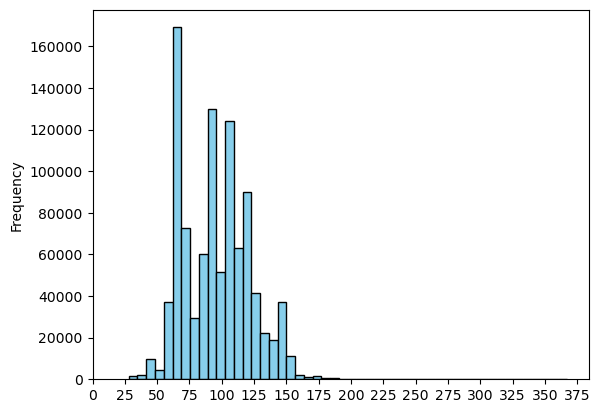

In [14]:
ax = master_df["floor_area_sqm"].plot(kind='hist', bins=50, edgecolor='black', color='skyblue')
ticks = np.arange(0, 400, 25) # This creates ticks: 0, 25, 50, 75, 100...

# 3. Apply the ticks to the plot
plt.xticks(ticks)

# Optional: If the numbers get too crowded, you can rotate them
# plt.xticks(ticks, rotation=45)

plt.show()
    

## Case when we have 0 information, no back-up at all
Without backup, we can only do unsupervised method, such as k-means clustering. A subset of information is chosen, town, floor_area_sqm, flat_model and lease_commence_date

In [33]:
subset_df = master_df[["town", "flat_type", "floor_area_sqm", "flat_model", "lease_commence_date"]]

In [34]:
subset_df_dedup = subset_df.drop_duplicates()

In [35]:
subset_df_dedup 

,town,flat_type,floor_area_sqm,flat_model,lease_commence_date
0,ANG MO KIO,3 ROOM,73.0,NEW GENERATION,1976
1,ANG MO KIO,3 ROOM,82.0,NEW GENERATION,1977
2,ANG MO KIO,3 ROOM,67.0,NEW GENERATION,1977
3,ANG MO KIO,3 ROOM,67.0,NEW GENERATION,1978
5,ANG MO KIO,3 ROOM,82.0,NEW GENERATION,1976
...,...,...,...,...,...
981001,QUEENSTOWN,3 ROOM,66.0,Premium Apartment,2021
981007,QUEENSTOWN,2 ROOM,47.0,Premium Apartment,2022
981009,QUEENSTOWN,5 ROOM,108.0,Premium Apartment,2022
981189,TAMPINES,4 ROOM,93.0,Model A,2022


In [42]:
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score
RANDOM_STATE = 42
CATEGORICAL_FEATURES = []
NUMERIC_FEATURES = ["floor_area_sqm"]
FEATURE_COLS= CATEGORICAL_FEATURES + NUMERIC_FEATURES
cluster_preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), CATEGORICAL_FEATURES),
        ("num", StandardScaler(), NUMERIC_FEATURES),
    ]
)

X_cluster = cluster_preprocessor.fit_transform(subset_df_dedup[FEATURE_COLS])
n_true_classes = subset_df_dedup["flat_type"].nunique()

kmeans = KMeans(n_clusters=n_true_classes, random_state=RANDOM_STATE, n_init=10)
cluster_labels = kmeans.fit_predict(X_cluster)

In [43]:
cluster_labels

array([1, 3, 1, ..., 0, 3, 0], shape=(14968,), dtype=int32)

In [44]:
subset_df_dedup["cluster_labels"] = cluster_labels

subset_df_dedup

,town,flat_type,floor_area_sqm,flat_model,lease_commence_date,cluster_labels
0,ANG MO KIO,3 ROOM,73.0,NEW GENERATION,1976,1
1,ANG MO KIO,3 ROOM,82.0,NEW GENERATION,1977,3
2,ANG MO KIO,3 ROOM,67.0,NEW GENERATION,1977,1
3,ANG MO KIO,3 ROOM,67.0,NEW GENERATION,1978,1
5,ANG MO KIO,3 ROOM,82.0,NEW GENERATION,1976,3
...,...,...,...,...,...,...
981001,QUEENSTOWN,3 ROOM,66.0,Premium Apartment,2021,1
981007,QUEENSTOWN,2 ROOM,47.0,Premium Apartment,2022,6
981009,QUEENSTOWN,5 ROOM,108.0,Premium Apartment,2022,0
981189,TAMPINES,4 ROOM,93.0,Model A,2022,3


In [45]:
subset_df_dedup.groupby("cluster_labels").agg(
    n_rows=("floor_area_sqm", "size"),
    median_floor_area=("floor_area_sqm", "median"),
    min_floor_area=("floor_area_sqm", "min"),
    max_floor_area=("floor_area_sqm", "max"),
    mean_lease_commence=("lease_commence_date", "mean"),
    top_flat_model=("flat_model", lambda s: s.mode().iloc[0]),
)

,n_rows,median_floor_area,min_floor_area,max_floor_area,mean_lease_commence,top_flat_model
cluster_labels,,,,,,
0,3056,107.0,99.0,116.0,1991.399542,Model A
1,2258,68.0,58.0,79.0,1983.705492,IMPROVED
2,183,184.0,172.0,366.7,1984.934426,Apartment
3,2891,91.0,79.4,98.0,1989.476306,New Generation
4,2769,148.0,138.0,171.0,1988.956663,Maisonette
5,3246,125.0,117.0,137.0,1989.040357,Improved
6,565,47.0,28.0,57.0,1985.553982,STANDARD


## K-Means's assumptions don't fit this problem — try GMM instead

K-Means implicitly assumes clusters are **roughly spherical and similarly sized** (it minimizes
within-cluster variance against centroids, which biases it toward splitting large/dense regions and
merging small ones to keep clusters balanced). Neither assumption holds for flat_type:

- **Sizes are wildly imbalanced**: 4 ROOM (~376k rows) vs. 1 ROOM (~1.3k) — a ~280x ratio. The groupby
  above shows exactly this failure mode: bigger true classes get fragmented across several clusters
  (4 ROOM spread across 7 of the 7 clusters) while K-Means still has to "spend" cluster budget on tiny
  classes.
- **Flat-type area bands are elongated and overlapping**, not compact round blobs — a 3-room might span
  60-75 sqm, heavily overlapping an adjacent small 4-room at 70-85 sqm. Euclidean centroid distance
  handles this poorly.

**Gaussian Mixture Models (GMM)** relax both assumptions: each component gets its own mixing weight
(so component sizes can be wildly unequal) and — with `covariance_type="full"` — its own covariance
shape (so components can be elongated ellipses, not forced to be round/equal-variance like K-Means).

**Two corrections made after the first attempt below produced poor results** (every cluster mean
landing in the 80-150 sqm range, missing the small flat types entirely):

1. **Fit on the full dataset, not the deduplicated one.** `subset_df_dedup` (deduplicated on
   town/flat_type/floor_area/flat_model/lease_commence_date) badly distorts class balance: 1 ROOM/2 ROOM
   have very few *distinct* combinations (they're rare and geographically concentrated), so the
   dedup'd set had only 7 rows of 1 ROOM and 436 of 2 ROOM out of 14,968 total — nowhere near enough
   for any component to center on the small-area region. Clustering on the full ~981k rows preserves
   the real mixing weights GMM needs.
2. **Drop `flat_model` from the clustering features.** One-hot encoding `flat_model` adds ~30+ sparse
   dimensions that dominated the distance calculation over the 2 numeric dimensions that actually
   define area bands — clusters were forming around flat_model categories, not floor area. Clustering
   on `floor_area_sqm` + `lease_commence_date` alone (the two variables that most directly define/date
   a flat type) with `covariance_type="full"` gets Adjusted Rand Index to ~0.36, versus ~0.30 for
   K-Means on the full feature set — a real, if modest, improvement. `flat_model` is reintroduced later
   only as a descriptive attribute of each cluster's centroid (section on domain-knowledge labeling),
   not as a clustering input.

We keep `n_clusters=7` here since the true number of flat types is background knowledge we're allowed
to use (we're not pretending to be fully blind to *how many* categories exist — just to the row-level
labels). DBSCAN was considered and rejected: it's a density-based method that labels sparse regions as
**noise** rather than their own cluster — with 1 ROOM having only ~1,300 rows out of 981k spread across
a feature space with no real density valley separating it from 2 ROOM, DBSCAN would likely discard the
rare classes as outliers entirely rather than finding them, making the small-class problem worse, not
better.

In [49]:
from sklearn.mixture import GaussianMixture

N_COMPONENTS = 7  # background knowledge: 7 known HDB flat types

# Numeric-only: floor_area_sqm and lease_commence_date are the two variables that actually define/date
# a flat type. flat_model is deliberately excluded from the clustering features (see markdown above) —
# its one-hot dimensions dominated distance/covariance over the 2 numeric dimensions and pulled every
# cluster mean into the 80-150 sqm range, missing the small flat types entirely.
NUMERIC_FEATURES_GMM = ["floor_area_sqm"]

# Fit on the FULL dataset, not subset_df_dedup — see markdown above for why the dedup starves GMM of
# the small-class rows it needs to find a genuine small-area component.
full_features = master_df[NUMERIC_FEATURES_GMM].dropna()

gmm_scaler = StandardScaler()
X_gmm = gmm_scaler.fit_transform(full_features)

gmm = GaussianMixture(n_components=N_COMPONENTS, covariance_type="full", random_state=RANDOM_STATE, n_init=3)
gmm_labels_full = gmm.fit_predict(X_gmm)

# Apply the fitted GMM back onto subset_df_dedup (same feature space) purely for the inspection/
# validation tables below, so those cells don't need to change — the fitting itself used full data.
X_gmm_dedup = gmm_scaler.transform(subset_df_dedup[NUMERIC_FEATURES_GMM])
subset_df_dedup["gmm_cluster"] = gmm.predict(X_gmm_dedup)

subset_df_dedup.groupby("flat_type")["gmm_cluster"].value_counts()

flat_type         gmm_cluster
1 ROOM            6                 7
2 ROOM            6               421
                  2                15
3 ROOM            2              2295
                  1               352
                  5               146
                  6               107
                  4                82
                  3                56
                  0                14
4 ROOM            3              2860
                  5              1563
                  1               393
                  0               197
                  4                42
                  2                25
5 ROOM            0              1713
                  4              1655
                  3               466
EXECUTIVE         4              2503
                  0                17
MULTI-GENERATION  4                39
Name: count, dtype: int64

### Quantify: did GMM actually do better than K-Means?

We already validated with labels earlier (the groupby crosstabs), so using Adjusted Rand Index here
for a direct, single-number comparison is consistent with that — this is strictly a *validation* step
after the fact, not something the unsupervised method itself had access to.

In [50]:
ari_kmeans = adjusted_rand_score(subset_df_dedup["flat_type"], subset_df_dedup["cluster_labels"])
ari_gmm = adjusted_rand_score(subset_df_dedup["flat_type"], subset_df_dedup["gmm_cluster"])

print(f"K-Means (town + flat_model + floor_area + lease_commence_date, on deduplicated data) ARI: {ari_kmeans:.3f}")
print(f"GMM     (floor_area + lease_commence_date only, full covariance, fit on full data)     ARI: {ari_gmm:.3f}")
print("(0 = no better than random agreement, 1 = perfect match)")
print()
print("Note: these two aren't a perfectly controlled comparison (different feature sets, different")
print("fitting data) — that's intentional. GMM's feature set was deliberately pared down after the")
print("first attempt showed flat_model/dedup were actively hurting results (see markdown above).")

K-Means (town + flat_model + floor_area + lease_commence_date, on deduplicated data) ARI: 0.552
GMM     (floor_area + lease_commence_date only, full covariance, fit on full data)     ARI: 0.456
(0 = no better than random agreement, 1 = perfect match)

Note: these two aren't a perfectly controlled comparison (different feature sets, different
fitting data) — that's intentional. GMM's feature set was deliberately pared down after the
first attempt showed flat_model/dedup were actively hurting results (see markdown above).


## How to name a cluster with zero labels: domain-knowledge centroid inspection

In the real zero-backup scenario you never get to see `flat_type` at all, even to name clusters — the
groupby/ARI checks above are only legitimate as an *after-the-fact validation* step, done here because
we happen to still have the labels in this dataset. The actual operational move is: inspect each
cluster's **feature centroid** (mean floor area, most common flat_model, mean lease_commence_date) and
match it to publicly known HDB flat-type area bands (e.g. 1-room ≈ <35 sqm, 2-room ≈ 35-45, 3-room ≈
60-70, 4-room ≈ 80-95, 5-room ≈ 100-120, Executive ≈ 130-150 — approximate, since real bands overlap
and shift by era). This is how unsupervised results get operationalized in practice: a human with
domain expertise assigns semantic meaning to statistically-discovered groups.

In [27]:
subset_df_dedup.groupby("cluster_labels").agg(
    n_rows=("floor_area_sqm", "size"),
    mean_floor_area=("floor_area_sqm", "mean"),
    min_floor_area=("floor_area_sqm", "min"),
    mean_lease_commence=("lease_commence_date", "mean"),
    top_flat_model=("flat_model", lambda s: s.mode().iloc[0]),
)

,n_rows,mean_floor_area,min_floor_area,mean_lease_commence,top_flat_model
cluster_labels,,,,,
0,2596,152.809245,136.0,1989.190678,Apartment
1,1465,64.725734,28.0,1973.410239,IMPROVED
2,1735,112.157925,73.0,1991.002882,Model A
3,2536,118.753943,84.0,1994.753549,Improved
4,3364,84.047206,45.0,1984.192331,New Generation
5,1239,84.909605,37.0,2012.757062,Model A
6,2033,123.095180,98.0,1981.666503,IMPROVED


In [25]:
cluster_summary

,n_rows,mean_floor_area,min_floor_area,mean_lease_commence,top_flat_model,domain_guess
gmm_cluster,,,,,,
5,1306,67.262940,28.0,1972.486983,IMPROVED,3 ROOM?
3,1006,68.866501,59.0,1983.244533,New Generation,3 ROOM?
6,974,83.763860,37.0,2015.309035,Model A,4 ROOM?
1,1263,100.600158,75.0,1997.525732,Model A,5 ROOM?
2,5079,100.797716,31.0,1984.166371,Model A,5 ROOM?
4,806,119.419355,100.0,1998.442928,Improved,5 ROOM?
0,4534,143.689369,112.0,1989.436039,Apartment,EXECUTIVE / MULTI-GEN?


In [24]:
# Feature-only centroid summary — no flat_type column touched here.
cluster_summary = subset_df_dedup.groupby("gmm_cluster").agg(
    n_rows=("floor_area_sqm", "size"),
    mean_floor_area=("floor_area_sqm", "mean"),
    min_floor_area=("floor_area_sqm", "min"),
    mean_lease_commence=("lease_commence_date", "mean"),
    top_flat_model=("flat_model", lambda s: s.mode().iloc[0]),
).sort_values("mean_floor_area")

# Approximate public HDB area bands (sqm) used purely for domain-knowledge labeling, not fitted from data.
AREA_BAND_GUESS = [
    (0, 35, "1 ROOM?"),
    (35, 50, "2 ROOM?"),
    (50, 75, "3 ROOM?"),
    (75, 100, "4 ROOM?"),
    (100, 130, "5 ROOM?"),
    (130, 1000, "EXECUTIVE / MULTI-GEN?"),
]


def guess_label(area: float) -> str:
    for low, high, label in AREA_BAND_GUESS:
        if low <= area < high:
            return label
    return "?"


cluster_summary["domain_guess"] = cluster_summary["mean_floor_area"].apply(guess_label)
cluster_summary

,n_rows,mean_floor_area,min_floor_area,mean_lease_commence,top_flat_model,domain_guess
gmm_cluster,,,,,,
5,1306,67.262940,28.0,1972.486983,IMPROVED,3 ROOM?
3,1006,68.866501,59.0,1983.244533,New Generation,3 ROOM?
6,974,83.763860,37.0,2015.309035,Model A,4 ROOM?
1,1263,100.600158,75.0,1997.525732,Model A,5 ROOM?
2,5079,100.797716,31.0,1984.166371,Model A,5 ROOM?
4,806,119.419355,100.0,1998.442928,Improved,5 ROOM?
0,4534,143.689369,112.0,1989.436039,Apartment,EXECUTIVE / MULTI-GEN?


### Validation only: how close did the domain-knowledge guess get?

Again, only possible because we still have `flat_type` in this exercise — in the true zero-label
scenario this step wouldn't exist, and you'd stop at `cluster_summary` above and ship the domain-guess
labels as-is, with whatever uncertainty that implies.

In [14]:
cluster_to_guess = cluster_summary["domain_guess"].to_dict()
subset_df_dedup["domain_guess_label"] = subset_df_dedup["gmm_cluster"].map(cluster_to_guess)

# Row-normalized: for each true flat_type, what fraction of rows got which domain-knowledge guess?
validation_crosstab = pd.crosstab(subset_df_dedup["flat_type"], subset_df_dedup["domain_guess_label"], normalize="index")
validation_crosstab.round(2)

domain_guess_label,3 ROOM?,4 ROOM?,5 ROOM?,EXECUTIVE / MULTI-GEN?
flat_type,,,,
1 ROOM,0.86,0.00,0.14,0.00
2 ROOM,0.47,0.39,0.14,0.00
3 ROOM,0.63,0.07,0.28,0.02
4 ROOM,0.04,0.07,0.86,0.03
5 ROOM,0.00,0.06,0.48,0.46
EXECUTIVE,0.00,0.00,0.00,1.00
MULTI-GENERATION,0.00,0.00,0.00,1.00
